# In-hospital mortality benchmark — tensor pickle

Loads **`mortality_for_coper.data`** (train/val/test tensors) from the mimic3-benchmarks pipeline. **Feature names** match the `Discretizer` (76 columns: channels + masks).

**Kernel:** `MIMIC/.venv-mimic` → `mimic-venv`.

For a **generic MIMIC-III presentation** (patients, notes, ICU trajectories), use `MIMIC/mimic3_exploration.ipynb`.

In [1]:
from __future__ import annotations

import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    display = print

MIMIC_BENCH = Path("/home/charlesv/Desktop/StatisitcalGenetics/MIMIC/mimic3-benchmarks").resolve()
sys.path.insert(0, str(MIMIC_BENCH))

from mimic3benchmark.readers import InHospitalMortalityReader  # noqa: E402
from mimic3models.preprocessing import Discretizer  # noqa: E402

data_root = MIMIC_BENCH / "data" / "in-hospital-mortality"
train_reader = InHospitalMortalityReader(
    dataset_dir=str(data_root / "train"),
    listfile=str(data_root / "train_listfile.csv"),
    period_length=48.0,
)
discretizer = Discretizer(
    timestep=1.0,
    store_masks=True,
    impute_strategy="previous",
    start_time="zero",
)
_, header_str = discretizer.transform(train_reader.read_example(0)["X"])
FEATURE_NAMES = header_str.split(",")
assert len(FEATURE_NAMES) == 76, len(FEATURE_NAMES)

PICKLE_PATH = MIMIC_BENCH / "data" / "mortality_for_coper.data"
print("Pickle:", PICKLE_PATH)
print("Features:", len(FEATURE_NAMES))

Pickle: /home/charlesv/Desktop/StatisitcalGenetics/MIMIC/mimic3-benchmarks/data/mortality_for_coper.data
Features: 76


## Load pickle

In [2]:
assert PICKLE_PATH.is_file(), f"Missing pickle: {PICKLE_PATH}"

with open(PICKLE_PATH, "rb") as f:
    details, X_train, y_train, X_val, y_val, X_test, y_test, _ = pickle.load(f)

print("details:", details)
Xs = {}
for name, X, y in [
    ("train", X_train, y_train),
    ("val", X_val, y_val),
    ("test", X_test, y_test),
]:
    X = np.asarray(X)
    y = np.asarray(y).reshape(-1)
    pos = int(y.sum())
    print(
        f"{name}: X={X.shape}  positive={pos:,}  negative={len(y) - pos:,}  "
        f"rate={y.mean():.4f}"
    )

details: {'format': 'mimic3-benchmarks in-hospital-mortality + discretizer/normalizer', 'timestep': 1.0, 'shapes': {'train': (14681, 48, 76), 'val': (3222, 48, 76), 'test': (3236, 48, 76)}}
train: X=(14681, 48, 76)  positive=1,987  negative=12,694  rate=0.1353
val: X=(3222, 48, 76)  positive=436  negative=2,786  rate=0.1353
test: X=(3236, 48, 76)  positive=374  negative=2,862  rate=0.1156


## Outcome counts (bar)

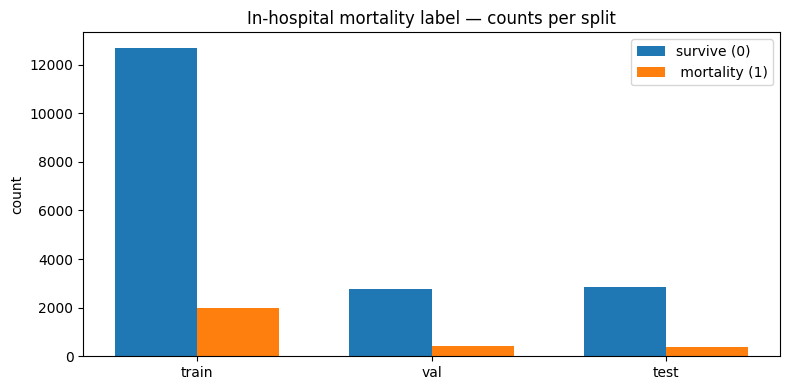

In [3]:
from collections import OrderedDict

labels = OrderedDict()
for name, X, y in [
    ("train", X_train, y_train),
    ("val", X_val, y_val),
    ("test", X_test, y_test),
]:
    y = np.asarray(y).reshape(-1)
    labels[name] = (int((y == 0).sum()), int((y == 1).sum()))

splits = list(labels.keys())
x = np.arange(len(splits))
w = 0.35
neg = [labels[s][0] for s in splits]
pos = [labels[s][1] for s in splits]
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w / 2, neg, w, label="survive (0)")
ax.bar(x + w / 2, pos, w, label=" mortality (1)")
ax.set_xticks(x)
ax.set_xticklabels(splits)
ax.set_ylabel("count")
ax.set_title("In-hospital mortality label — counts per split")
ax.legend()
plt.tight_layout()
plt.show()

## Feature–feature correlation (subsample)

Mean over **48 hours** per stay → shape **(N, 76)**, then Pearson correlation between features. **Subsample** stays for speed; masks are included.

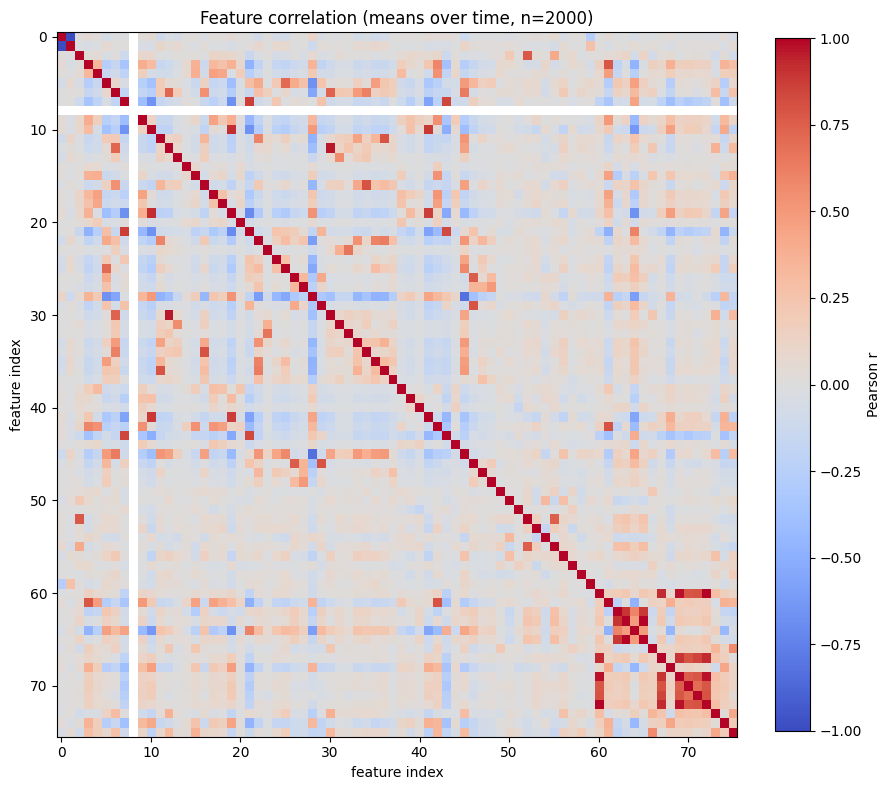

In [4]:
rng = np.random.default_rng(0)
X = np.asarray(X_train)
y = np.asarray(y_train).reshape(-1)
nmax = 2000
if X.shape[0] > nmax:
    idx = rng.choice(X.shape[0], size=nmax, replace=False)
    Xsamp = X[idx]
    ysamp = y[idx]
else:
    Xsamp = X
    ysamp = y

feat = Xsamp.mean(axis=1)  # (n, 76)
df_f = pd.DataFrame(feat, columns=FEATURE_NAMES)
C = df_f.corr().values

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(C, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, fraction=0.046, label="Pearson r")
ax.set_title(f"Feature correlation (means over time, n={nmax})")
ax.set_xlabel("feature index")
ax.set_ylabel("feature index")
plt.tight_layout()
# Save before plt.show() — show() clears the figure in some backends (would save a blank PNG)
_out_corr = "/home/charlesv/Desktop/StatisitcalGenetics/pictures/correlation_features_mortality.png"
fig.savefig(_out_corr, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()


## Outcome vs feature (point-biserial on mean per stay)

Correlation of **label** with **time-averaged** feature (same subsample as above).

/home/charlesv/Desktop/StatisitcalGenetics/code/COPER/.venv-coper/lib64/python3.14/site-packages/scipy/stats/_stats_py.py:5523: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)


,j,feature,r_pb,p_value
4,4,Glascow coma scale eye opening->To Pain,0.163143,2.125778e-13
15,15,Glascow coma scale motor response->No response,0.156548,1.920996e-12
6,6,Glascow coma scale eye opening->1 No Response,0.155981,2.311375e-12
43,43,Glascow coma scale verbal response->5 Oriented,-0.136838,8.012082e-10
21,21,Glascow coma scale motor response->6 Obeys Com...,-0.136252,9.467927e-10
61,61,mask->Fraction inspired oxygen,0.130299,4.961584e-09
55,55,Systolic blood pressure,-0.129005,7.044370e-09
12,12,Glascow coma scale motor response->1 No Response,0.124438,2.360201e-08
30,30,Glascow coma scale total->3,0.123254,3.206925e-08
31,31,Glascow coma scale total->5,0.123237,3.220909e-08


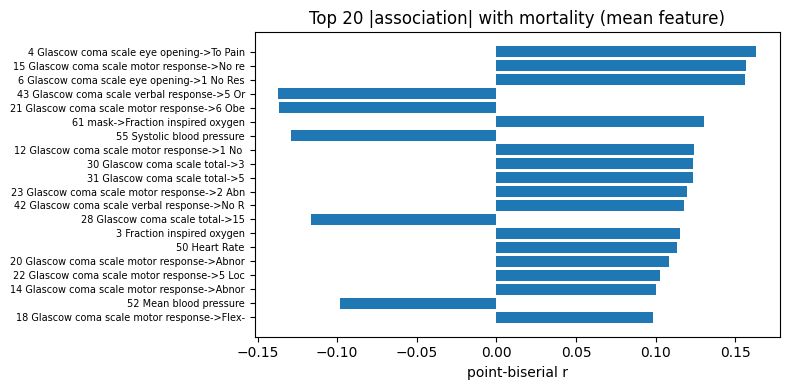

In [5]:
from scipy import stats

rows = []
for j, name in enumerate(FEATURE_NAMES):
    col = feat[:, j]
    r, p = stats.pointbiserialr(ysamp.astype(float), col)
    rows.append({"j": j, "feature": name, "r_pb": r, "p_value": p})
assoc = pd.DataFrame(rows)
assoc["_abs"] = assoc["r_pb"].abs()
assoc = assoc.sort_values("_abs", ascending=False).drop(columns="_abs")
display(assoc.head(15))

fig, ax = plt.subplots(figsize=(8, 4))
top = assoc.head(20).iloc[::-1]
ax.barh(range(len(top)), top["r_pb"].values)
ax.set_yticks(range(len(top)))
lbl = [f"{int(row['j'])} {str(row['feature'])[:40]}" for _, row in top.iterrows()]
ax.set_yticklabels(lbl, fontsize=7)
ax.set_xlabel("point-biserial r")
ax.set_title("Top 20 |association| with mortality (mean feature)")
plt.tight_layout()
_out_assoc = "/home/charlesv/Desktop/StatisitcalGenetics/pictures/association_features_mortality.png"
fig.savefig(_out_assoc, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()


## Feature names

In [6]:
name_table = pd.DataFrame({"j": np.arange(76), "feature_name": FEATURE_NAMES})
print(name_table.to_string(index=False))

 j                                                feature_name
 0                                  Capillary refill rate->0.0
 1                                  Capillary refill rate->1.0
 2                                    Diastolic blood pressure
 3                                    Fraction inspired oxygen
 4                     Glascow coma scale eye opening->To Pain
 5                 Glascow coma scale eye opening->3 To speech
 6               Glascow coma scale eye opening->1 No Response
 7             Glascow coma scale eye opening->4 Spontaneously
 8                        Glascow coma scale eye opening->None
 9                   Glascow coma scale eye opening->To Speech
10               Glascow coma scale eye opening->Spontaneously
11                   Glascow coma scale eye opening->2 To pain
12            Glascow coma scale motor response->1 No Response
13         Glascow coma scale motor response->3 Abnorm flexion
14       Glascow coma scale motor response->Abnormal ex

## Example heatmap (train)

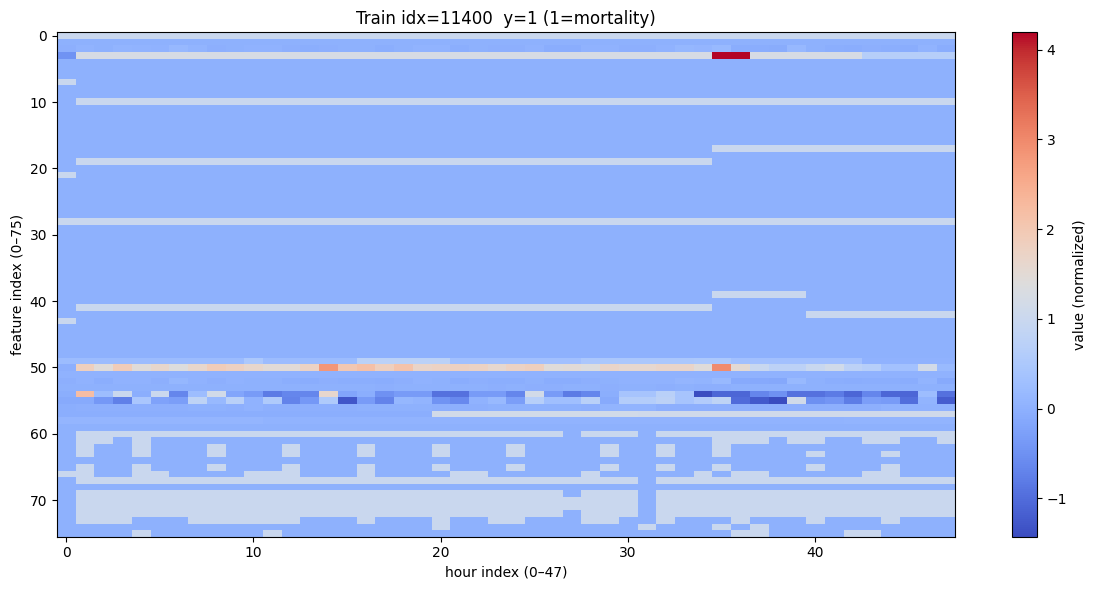

In [7]:
rng = np.random.default_rng(10)
idx = int(rng.integers(0, X_train.shape[0]))
x1 = np.asarray(X_train[idx])
y1 = float(np.asarray(y_train).reshape(-1)[idx])

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(x1.T, aspect="auto", cmap="coolwarm", interpolation="nearest")
plt.colorbar(im, ax=ax, label="value (normalized)")
ax.set_xlabel("hour index (0–47)")
ax.set_ylabel("feature index (0–75)")
ax.set_title(f"Train idx={idx}  y={y1:.0f} (1=mortality)")
plt.tight_layout()
plt.show()